# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [13]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import re

from kagglehub import KaggleDatasetAdapter
from sentence_transformers import SentenceTransformer, util
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [14]:
df = pd.read_csv('..\dataset_raw.csv')
df.head()

,Release Year,Title,Origin/Ethnicity,Director,Cast,Genre,Wiki Page,Plot
0,1901,Kansas Saloon Smashers,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/Kansas_Saloon_Sm...,"A bartender is working at a saloon, serving dr..."
1,1901,Love by the Light of the Moon,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/Love_by_the_Ligh...,"The moon, painted with a smiling face hangs ov..."
2,1901,The Martyred Presidents,American,Unknown,NaN,unknown,https://en.wikipedia.org/wiki/The_Martyred_Pre...,"The film, just over a minute long, is composed..."
3,1901,"Terrible Teddy, the Grizzly King",American,Unknown,NaN,unknown,"https://en.wikipedia.org/wiki/Terrible_Teddy,_...",Lasting just 61 seconds and consisting of two ...
4,1902,Jack and the Beanstalk,American,"George S. Fleming, Edwin S. Porter",NaN,unknown,https://en.wikipedia.org/wiki/Jack_and_the_Bea...,The earliest known adaptation of the classic f...


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

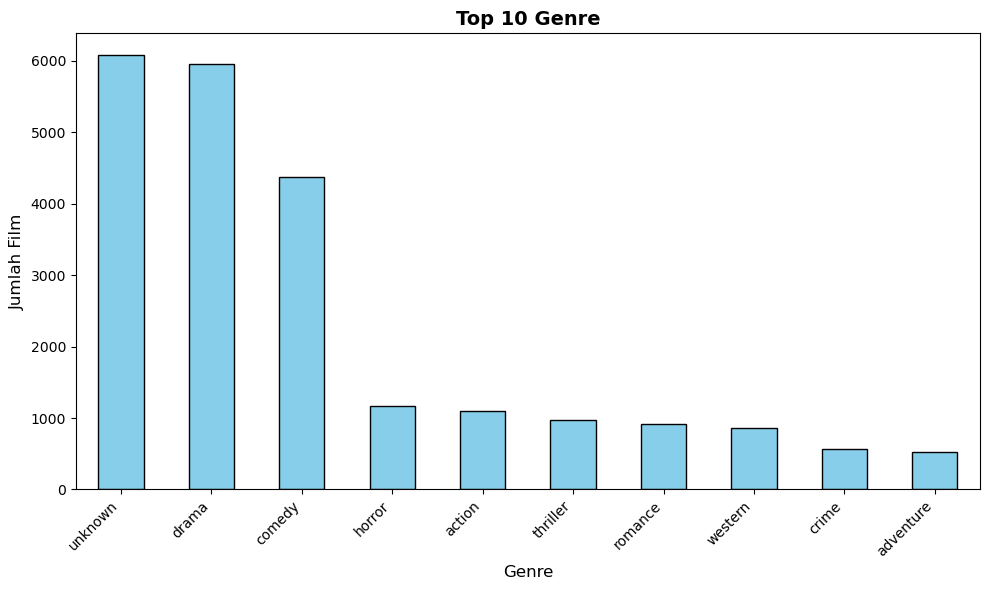

In [15]:
# Top 10 Genre sebelum mapping
top_genres = df['Genre'].value_counts().sort_values(ascending=False)[0:10]

plt.figure(figsize=(10, 6)) # Mengatur ukuran kanvas grafik
top_genres.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Tambahkan Judul dan Label Keterangan
plt.title('Top 10 Genre', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Jumlah Film', fontsize=12)

# Memutar teks label genre agar tidak saling tabrakan jika namanya panjang
plt.xticks(rotation=45, ha='right') 

# 4. Tampilkan Grafik
plt.tight_layout() # Menyesuaikan layout agar tidak ada teks yang terpotong
plt.show()

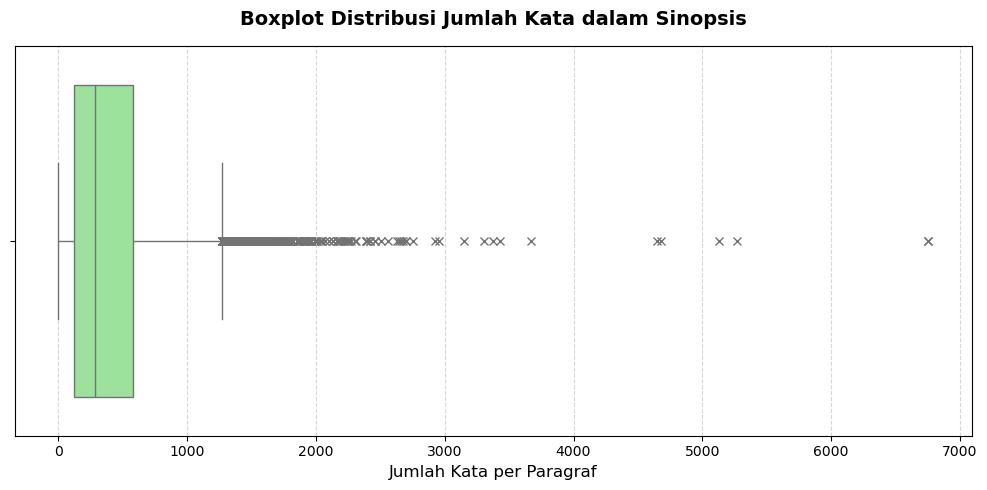

In [16]:
df['Jumlah_Kata'] = df['Plot'].str.split().str.len()

plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Jumlah_Kata'], color='lightgreen', flierprops={"marker": "x", "markerfacecolor": "red"})

plt.title('Boxplot Distribusi Jumlah Kata dalam Sinopsis', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Kata per Paragraf', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

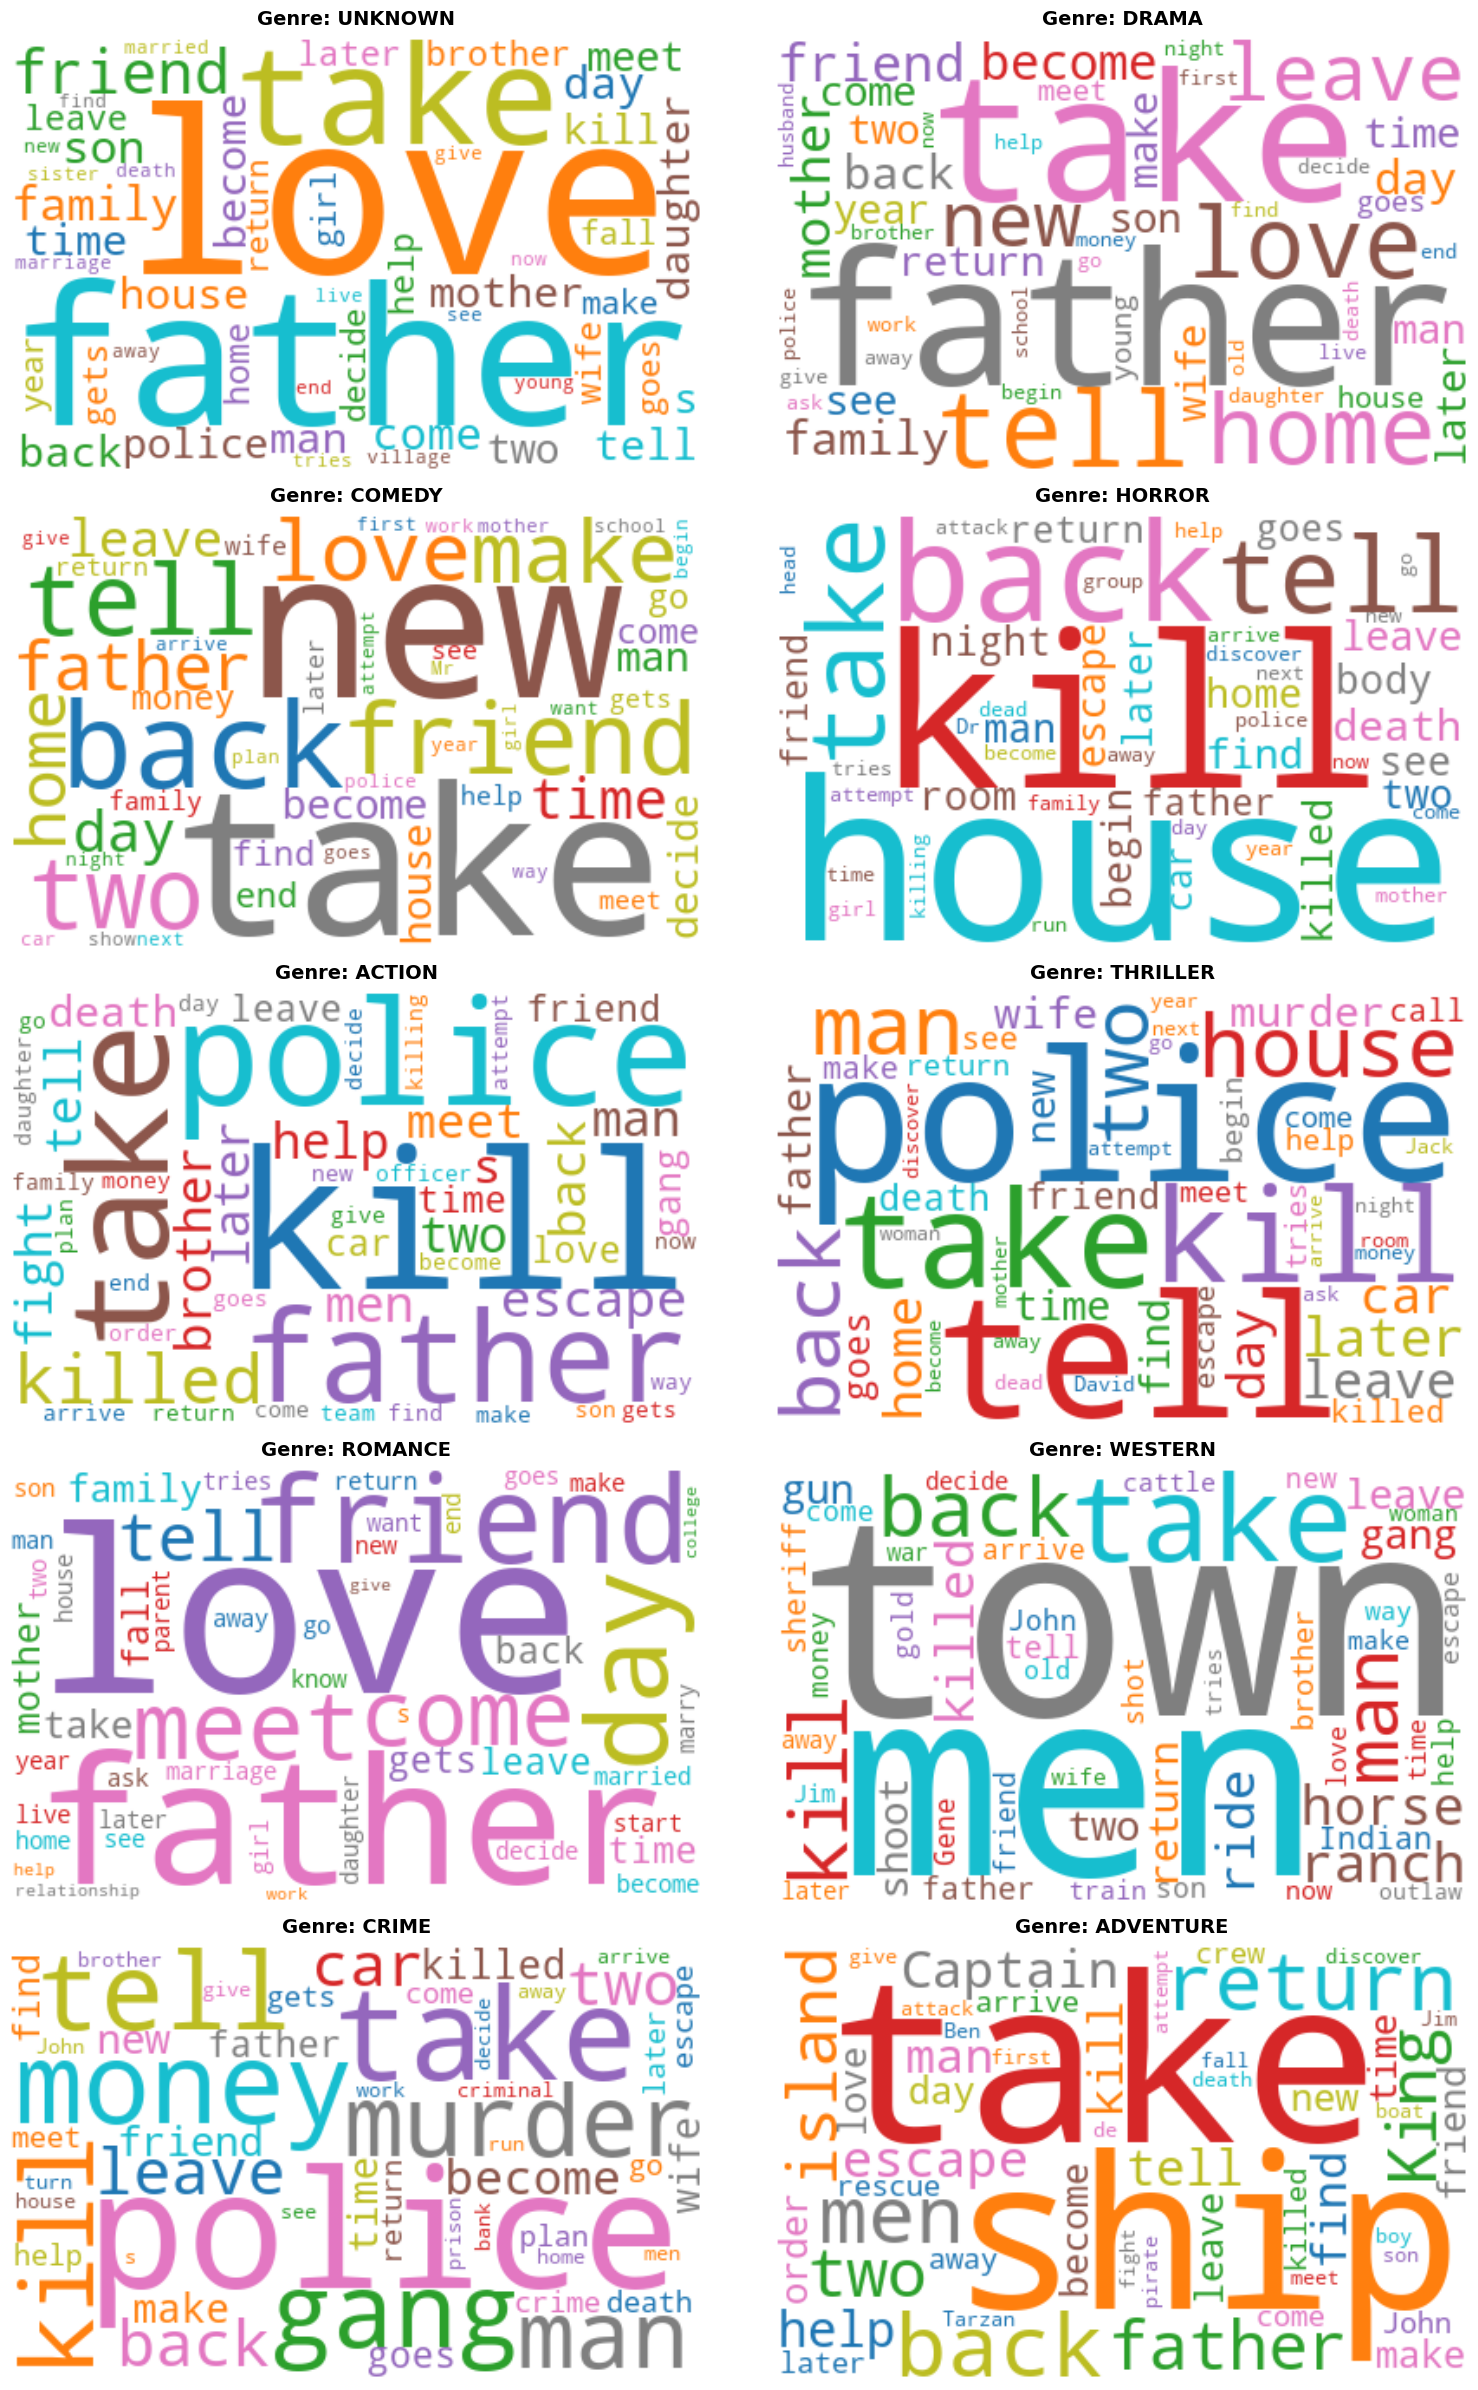

In [17]:
top_genres = df['Genre'].value_counts().nlargest(10).index.tolist()

kata_diabaikan = set(STOPWORDS)
kata_diabaikan.update(["movie", "film", "story", "plot", "one", "will", "life", "finds"])

fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

for i, genre in enumerate(top_genres):
    teks_per_genre = " ".join(df[df['Genre'] == genre]['Plot'].astype(str).tolist())
    
    wc = WordCloud(
        background_color='white',
        max_words=50,
        stopwords=kata_diabaikan,
        width=400,
        height=250,
        colormap='tab10',
        collocations=False
    )
    
    if teks_per_genre.strip():
        wc.generate(teks_per_genre)
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'Genre: {genre.upper()}', fontsize=14, fontweight='bold', pad=10)
    else:
        axes[i].text(0.5, 0.5, 'Data Tidak Cukup', ha='center', va='center', fontsize=12)
        
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [18]:
# Copy dataset & get genre and plot only
clean_df = df.copy()
clean_df = clean_df[['Genre', 'Plot']]
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34886 entries, 0 to 34885
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Genre   34886 non-null  object
 1   Plot    34886 non-null  object
dtypes: object(2)
memory usage: 545.2+ KB


Untuk dataset ini, kita persempit menjadi 4 genre {drama, comedy, horror, action}, selain itu kita ignore

In [19]:
# Remove duplicate and null value
clean_df = clean_df.dropna(subset=['Genre', 'Plot'], ignore_index=True)

clean_df = clean_df.drop_duplicates(subset=['Plot'], ignore_index=True)

clean_df['Genre'] = clean_df['Genre'].astype(str).str.strip().str.replace(r'\s+', '', regex=True)
clean_df = clean_df[clean_df['Genre'].str.lower().isin(['drama', 'comedy', 'horror', 'action'])]

clean_df['Genre'].value_counts()

Genre
drama     5883
comedy    4351
horror    1147
action    1077
Name: count, dtype: int64

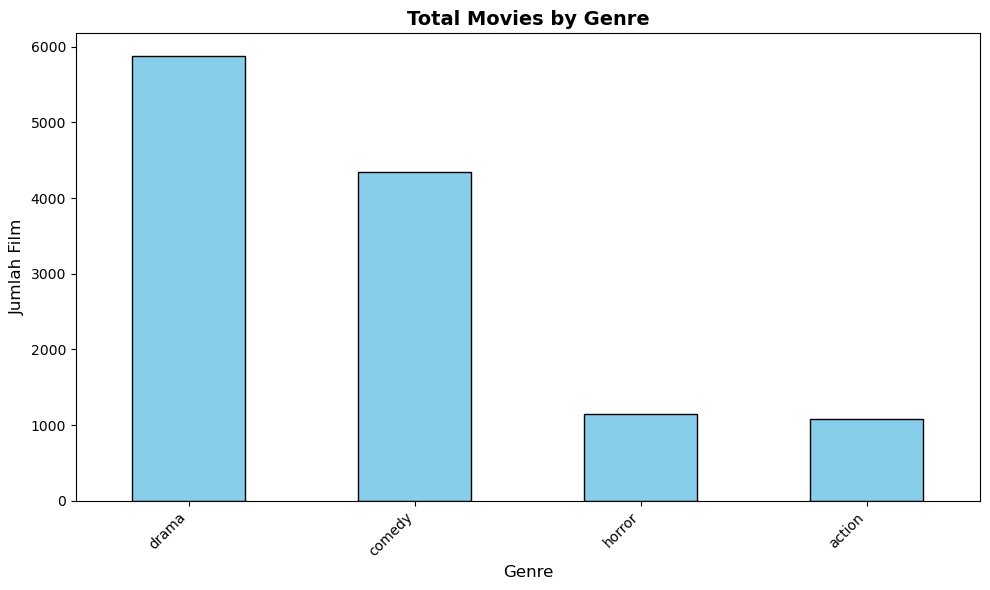

In [20]:
genre_counts = clean_df['Genre'].value_counts()

plt.figure(figsize=(10, 6)) # Mengatur ukuran kanvas grafik
genre_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# 3. Tambahkan Judul dan Label Keterangan
plt.title('Total Movies by Genre', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Jumlah Film', fontsize=12)

# Memutar teks label genre agar tidak saling tabrakan jika namanya panjang
plt.xticks(rotation=45, ha='right') 

# 4. Tampilkan Grafik
plt.tight_layout() # Menyesuaikan layout agar tidak ada teks yang terpotong
plt.show()

In [21]:
# Undersampling drama & comedy

df_drama = clean_df[clean_df['Genre'].str.lower() == 'drama']
df_comedy = clean_df[clean_df['Genre'].str.lower() == 'comedy']
df_horror = clean_df[clean_df['Genre'].str.lower() == 'horror']
df_action = clean_df[clean_df['Genre'].str.lower() == 'action']

target_sample = 2500

df_drama_sampled = df_drama.sample(n=target_sample, random_state=42)
df_comedy_sampled = df_comedy.sample(n=target_sample, random_state=42)

balanced_df = pd.concat([
    df_drama_sampled, 
    df_comedy_sampled, 
    df_horror, 
    df_action
])

balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(balanced_df['Genre'].value_counts())

Genre
drama     2500
comedy    2500
horror    1147
action    1077
Name: count, dtype: int64


In [22]:
# Inisialisasi library & dictionary
nltk_tokenizer = word_tokenize
en_stopwords = list(stopwords.words("english"))
slang_csv_url = "https://raw.githubusercontent.com/Abhay-211/slang-normalizer/refs/heads/main/abbreviations.csv"
slang_dict = pd.read_csv(slang_csv_url, sep=',', header=None, names=["slang", "formal"]).set_index('slang')["formal"].to_dict()
porter_stemmer = PorterStemmer()

def preprocessing(text, tokenizer=nltk_tokenizer, stopwords_list=en_stopwords, slang_dictionary=slang_dict, stemmer=porter_stemmer):
    try:
        text = str(text)
        
        text = re.sub(r'@[A-Za-z0-9]+', '', text)
        text = re.sub(r'#[A-Za-z0-9]+', '', text)
        text = re.sub(r"http\S+", '', text)
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = re.sub(r'\s+', ' ', text)
        cleaned = text.strip()
    
        case_folded = cleaned.lower()
    
        tokenized = tokenizer(case_folded)
    
        stopword_removed = [token for token in tokenized if token not in stopwords_list]
    
        slang_normalized = [slang_dictionary.get(token, token) for token in stopword_removed]
    
        final = [stemmer.stem(token) for token in slang_normalized]
    
        return {
            "cleaned": cleaned,
            "case_folded": case_folded,
            "tokenized": tokenized,
            "stopword_removed": stopword_removed,
            "slang_normalized": slang_normalized,
            "final": final,
        }
    except Exception as e:
        print(f"\nError pada baris teks: {str(e)}")
        raise e


preprocess_result_dict = []
total_rows = len(clean_df)

# Menggunakan enumerate untuk mendapatkan indeks (dimulai dari 1 agar lebih natural dibaca)
for idx, review in enumerate(balanced_df['Plot'], start=1):
    # Print status baris saat ini
    print(f"Memproses baris ke-{idx} dari {total_rows}...", end="\r", flush=True)
    
    result = preprocessing(review)
    preprocess_result_dict.append(result)

# Berikan print kosong di akhir agar output berikutnya tidak menimpa baris status terakhir
print("\nPreprocessing selesai!")

# Menggabungkan hasil kembali ke DataFrame utama
balanced_df = pd.DataFrame.join(balanced_df, pd.DataFrame.from_dict(preprocess_result_dict))
balanced_df

Memproses baris ke-7224 dari 12458...
Preprocessing selesai!


,Genre,Plot,cleaned,case_folded,tokenized,stopword_removed,slang_normalized,final
0,drama,A crusading and reform-minded District Attorne...,A crusading and reformminded District Attorney...,a crusading and reformminded district attorney...,"[a, crusading, and, reformminded, district, at...","[crusading, reformminded, district, attorney, ...","[crusading, reformminded, district, attorney, ...","[crusad, reformmind, district, attorney, resig..."
1,action,Sivagiri (Vijay) is a bladesmith in a remote v...,Sivagiri Vijay is a bladesmith in a remote vil...,sivagiri vijay is a bladesmith in a remote vil...,"[sivagiri, vijay, is, a, bladesmith, in, a, re...","[sivagiri, vijay, bladesmith, remote, village,...","[sivagiri, vijay, bladesmith, remote, village,...","[sivagiri, vijay, bladesmith, remot, villag, n..."
2,drama,The Blackbird (Lon Chaney) is a thief who uses...,The Blackbird Lon Chaney is a thief who uses a...,the blackbird lon chaney is a thief who uses a...,"[the, blackbird, lon, chaney, is, a, thief, wh...","[blackbird, lon, chaney, thief, uses, second, ...","[blackbird, lon, chaney, thief, uses, second, ...","[blackbird, lon, chaney, thief, use, second, i..."
3,comedy,Three British naval officers out on a drunken ...,Three British naval officers out on a drunken ...,three british naval officers out on a drunken ...,"[three, british, naval, officers, out, on, a, ...","[three, british, naval, officers, drunken, spr...","[three, british, naval, officers, drunken, spr...","[three, british, naval, offic, drunken, spree,..."
4,action,Mild-mannered reporter Clark Kent and Lois Lan...,Mildmannered reporter Clark Kent and Lois Lane...,mildmannered reporter clark kent and lois lane...,"[mildmannered, reporter, clark, kent, and, loi...","[mildmannered, reporter, clark, kent, lois, la...","[mildmannered, reporter, clark, kent, lois, la...","[mildmann, report, clark, kent, loi, lane, sen..."
...,...,...,...,...,...,...,...,...
7219,comedy,Albert Toddey (Jason) who daydreams of being a...,Albert Toddey Jason who daydreams of being a J...,albert toddey jason who daydreams of being a j...,"[albert, toddey, jason, who, daydreams, of, be...","[albert, toddey, jason, daydreams, james, bond...","[albert, toddey, jason, daydreams, james, bond...","[albert, toddey, jason, daydream, jame, bond, ..."
7220,horror,"In Rome, American diplomat Robert Thorn (Grego...",In Rome American diplomat Robert Thorn Gregory...,in rome american diplomat robert thorn gregory...,"[in, rome, american, diplomat, robert, thorn, ...","[rome, american, diplomat, robert, thorn, greg...","[rome, american, diplomat, robert, thorn, greg...","[rome, american, diplomat, robert, thorn, greg..."
7221,horror,A young bride is murdered on her wedding day b...,A young bride is murdered on her wedding day b...,a young bride is murdered on her wedding day b...,"[a, young, bride, is, murdered, on, her, weddi...","[young, bride, murdered, wedding, day, man, re...","[young, bride, murdered, wedding, day, man, re...","[young, bride, murder, wed, day, man, reject, ..."
7222,horror,"Leatherface bludgeons a young woman, Gina, to ...",Leatherface bludgeons a young woman Gina to de...,leatherface bludgeons a young woman gina to de...,"[leatherface, bludgeons, a, young, woman, gina...","[leatherface, bludgeons, young, woman, gina, d...","[leatherface, bludgeons, young, woman, gina, d...","[leatherfac, bludgeon, young, woman, gina, dea..."


In [27]:
#Save dataset
final_df = balanced_df[['Plot', 'final']]
final_df.to_csv('dataset_preprocessing.csv', index=False)